In [9]:
import io
import glob
import os
import re
import sys
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
import numpy as np
import zstandard as zstd
import xarray as xr
import pyart

sys.path.append("/home/robbyfrost/Analysis/MetroWX_Lidar/2026/")
from process import reprocess_moments_fast
from plot_ppi import prep_for_plot, plot_ppi

sys.path.append("/home/robbyfrost/Analysis/TurbTor_Radar/")
from functions import dis_angle_to_2Dxy, north0_to_arctheta, snr_cmap

# plotting set up
from matplotlib import rc
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=15)
rc('figure', facecolor='white')

In [10]:
# params
jt = 25
swp = 0
az_off = 330 # degrees
xbds = [0,5]
ybds = [0,5]

# files
dlid = "/data/arrcwx/MetroWeather/ARRC_MCDL/2026/202604/20260412/"
scan = "CAPPI" # CAPPI, Pointing, RHI, or PPI
files = sorted(glob.glob(f"{dlid}*{scan}*"))

# read file
dctx = zstd.ZstdDecompressor()
with open(files[jt], 'rb') as f:
    raw = dctx.decompress(f.read())
ds = xr.open_dataset(io.BytesIO(raw), engine='h5netcdf')

In [11]:
# prep for plotting
def prep_for_plot(ds, swp=0, az_off=0):

    ds = reprocess_moments_fast(ds)
    ds = ds.where(ds.R >= 0, drop=True)

    fixed_angle = np.unique(ds.elevation.values)
    ds = ds.where(ds.elevation == fixed_angle[swp], drop=True)
    ds['R'] = ds.R[:,0]

    ds['AZC'] = ds.azimuth + az_off

    x, y = dis_angle_to_2Dxy(
        ds.R.values,
        north0_to_arctheta(ds.AZC.values[:,0])
    )
    x, y = x.T, y.T
    ds = ds.assign({
        'x': xr.DataArray(x, dims=['ntime', 'nrange']),
        'y': xr.DataArray(y, dims=['ntime', 'nrange'])
    })
    return ds

ds_swp = prep_for_plot(ds, swp, az_off)

/home/robbyfrost/Analysis/MetroWX_Lidar/2026/process.py:216: RuntimeWarning: divide by zero encountered in log10
  SNR[it, :] = np.where(gatesnr > 0, 10*np.log10(gatesnr), np.nan)
/home/robbyfrost/Analysis/MetroWX_Lidar/2026/process.py:217: RuntimeWarning: divide by zero encountered in log10
  REF[it, :] = np.where(gatesnr > 0, 10*np.log10(gatesnr * np.power(R-R[r0], 2)), np.nan)
/home/robbyfrost/Analysis/MetroWX_Lidar/2026/process.py:218: RuntimeWarning: All-NaN slice encountered
  peaks_a,peaks_b = np.where(gatesignal > np.nanmax(gatesignal,axis=1)[:,np.newaxis]*THRESHOLD_NORMPEAKFIND)  # peak location at different range gate
/home/robbyfrost/Analysis/MetroWX_Lidar/2026/process.py:224: RuntimeWarning: invalid value encountered in divide
  peakest = sum_wx / sum_w  # weighted avg index per gate
/home/robbyfrost/Analysis/MetroWX_Lidar/2026/process.py:229: RuntimeWarning: invalid value encountered in divide
  SW[it] = np.sqrt(sum_wx2 / sum_w)
/home/robbyfrost/Analysis/MetroWX_Lidar/2026

/tmp/ipykernel_926532/1656850203.py:21: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(
/tmp/ipykernel_926532/1656850203.py:36: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(
/tmp/ipykernel_926532/1656850203.py:49: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(


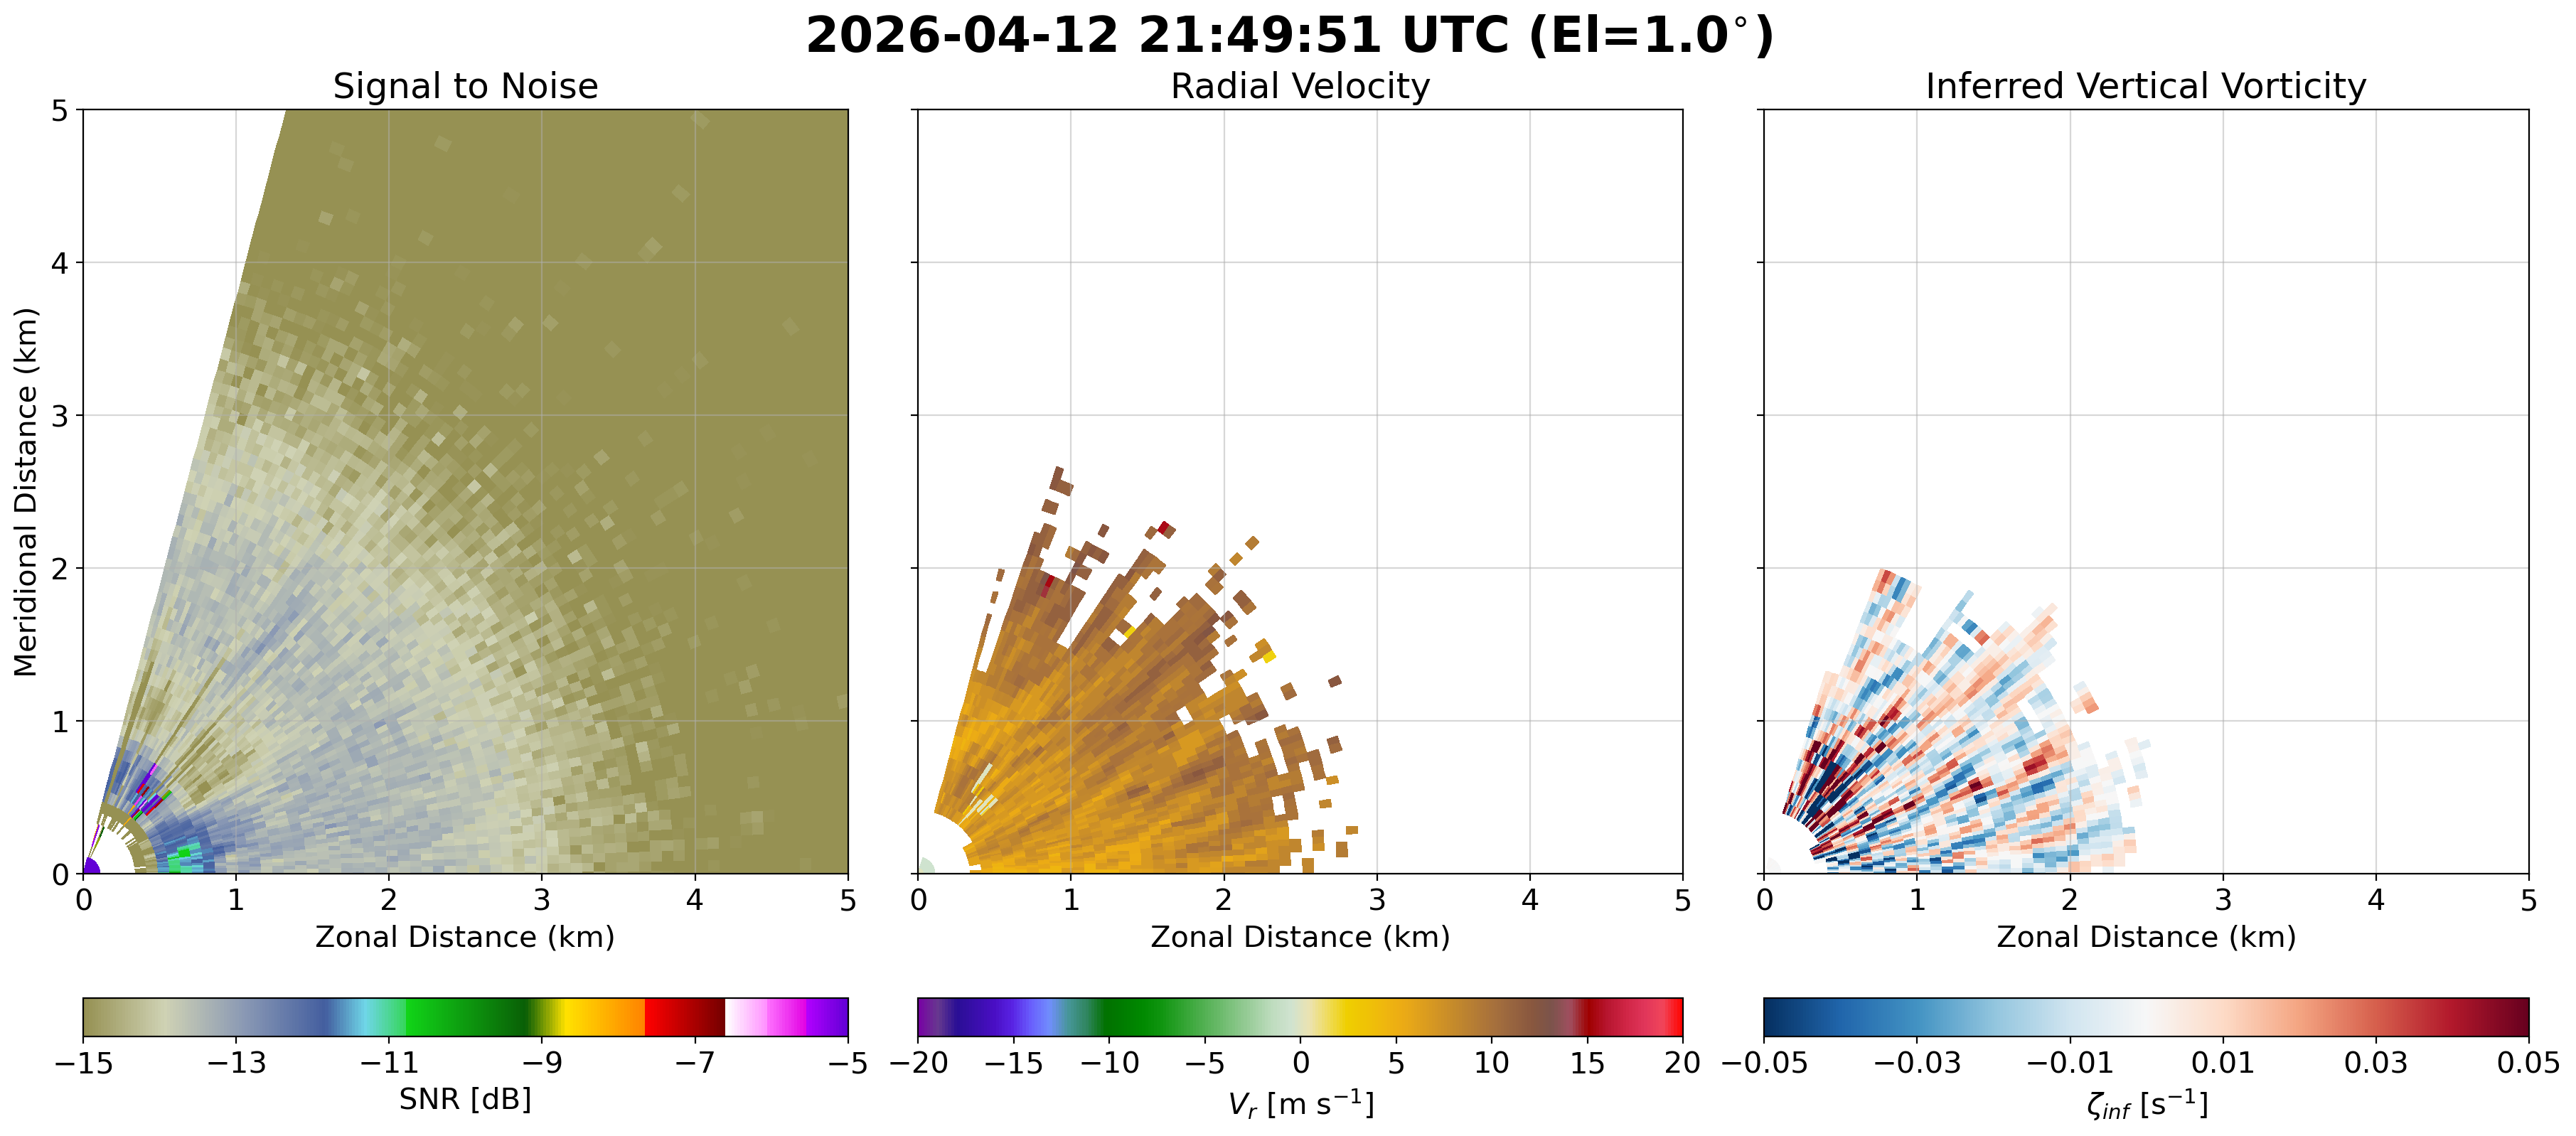

In [12]:
fixed_angle = np.unique(ds.elevation.values)
tplot = datetime.fromtimestamp(float(ds_swp.start_time[0,0].values) / 1e6, tz=timezone.utc)
tplot = str(tplot)[:-13]

# make fig
fig, axs = plt.subplots(
    figsize=(18,7.85),
    ncols=3,
    sharey=True,
    sharex=True,
    constrained_layout=True,
    dpi=200
)
fig.suptitle(f"{tplot} UTC (El={fixed_angle[swp]:.1f}$^{{\\circ}}$)",
            fontsize=25,
            fontweight='bold')
# snr
ax = axs[0]
vmin, vmax = -15, -5
ax.set_title("Signal to Noise")
pcm = ax.pcolormesh(
    ds_swp.x/1e3,
    ds_swp.y/1e3,
    ds_swp.SNR_OU,
    cmap=snr_cmap(),
    vmin=vmin,
    vmax=vmax
)
cbar = plt.colorbar(pcm, ax=ax, label="SNR [dB]", orientation='horizontal')
cbar.set_ticks(np.arange(vmin, vmax+1e-10, 2))
ax.set_ylabel("Meridional Distance (km)")
# radial velocity
ax = axs[1]
vmin, vmax = -20, 20
ax.set_title("Radial Velocity")
pcm = ax.pcolormesh(
    ds_swp.x/1e3,
    ds_swp.y/1e3,
    ds_swp.VRC_OU,
    cmap='pyart_Carbone42',
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(pcm, ax=ax, label="$V_r$ [m s$^{-1}$]", orientation='horizontal')
# inferred vertical vorticity
ax = axs[2]
vmin, vmax = -0.05, 0.05
ax.set_title("Inferred Vertical Vorticity")
pcm = ax.pcolormesh(
    ds_swp.x/1e3,
    ds_swp.y/1e3,
    ds_swp.VORTS_OU,
    cmap='RdBu_r',
    vmin=vmin,
    vmax=vmax
)
cbar = plt.colorbar(pcm, ax=ax, label="$\\zeta_{inf}$ [s$^{-1}$]", orientation='horizontal')
cbar.set_ticks(np.arange(vmin, vmax+1e-10, 0.02))

# clean up
for ax in axs:
    ax.set_xlabel("Zonal Distance (km)")
    ax.set_aspect('equal')
    ax.grid(alpha=0.5)
    ax.set_xlim(xbds)
    ax.set_ylim(ybds)